In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../../DataSets/diabetes.csv")

In [51]:
cols=list(df.columns)
print(cols)

['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi', 'pedigree', 'age', 'label']


In [52]:
lbl ="label"

In [53]:
from sklearn.tree import DecisionTreeClassifier
# create decision tree classifier object
clf = DecisionTreeClassifier(criterion="entropy",max_depth=3)

In [54]:
df.head()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [55]:
cols.remove(lbl)
feature_cols = cols
print (feature_cols)

['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi', 'pedigree', 'age']


In [56]:
X = df[feature_cols] # Features
y = df[lbl] # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state= 1)

In [57]:
#Train Classifer

model = clf.fit(X_train, y_train)
#predit the response for the dataset
y_pred = model.predict(X_test)

In [58]:
#Claculate accurracy
from sklearn import metrics

In [59]:
result = metrics.confusion_matrix(y_test, y_pred)
print ("Confusion Matrix:")
print (result)

Confusion Matrix:
[[124  22]
 [ 31  54]]


In [60]:
# [row, column]
TP = result [1,1]
TN = result [0,0]
FP = result [0,1]
FN = result [1,0]

In [61]:
print("Accuracy:\t",metrics.accuracy_score(y_test, y_pred))
print("Sensitivity:\t",metrics.recall_score(y_test, y_pred))
print("Specificity:\t",TN / (TN + FP))
print("Precision:\t",metrics.precision_score(y_test, y_pred))
print("Classification Eerror:", 1 - metrics.accuracy_score(y_test, y_pred))
print("False_Positive_Rate:",1 - TN / (TN + FP))

Accuracy:	 0.7705627705627706
Sensitivity:	 0.6352941176470588
Specificity:	 0.8493150684931506
Precision:	 0.7105263157894737
Classification Eerror: 0.22943722943722944
False_Positive_Rate: 0.15068493150684936


In [62]:
def ClsMdl(y_test, y_pred, TN, TP, FN, FP):
    """Display classification model metrics"""
    print("Classification Model Metrics:")
    print("=" * 50)
    print(f"True Negatives (TN):  {TN}")
    print(f"True Positives (TP):  {TP}")
    print(f"False Negatives (FN): {FN}")
    print(f"False Positives (FP): {FP}")
    print("=" * 50)
    print(f"Accuracy:   {metrics.accuracy_score(y_test, y_pred):.4f}")
    print(f"Sensitivity: {TP / (TP + FN):.4f}")
    print(f"Specificity: {TN / (TN + FP):.4f}")
    print(f"Precision:  {TP / (TP + FP):.4f}")
    print(f"F1-Score:   {2 * (TP / (TP + FP)) * (TP / (TP + FN)) / ((TP / (TP + FP)) + (TP / (TP + FN))):.4f}")

In [63]:
ClsMdl(y_test, y_pred, TN, TP, FN, FP)

Classification Model Metrics:
True Negatives (TN):  124
True Positives (TP):  54
False Negatives (FN): 31
False Positives (FP): 22
Accuracy:   0.7706
Sensitivity: 0.6353
Specificity: 0.8493
Precision:  0.7105
F1-Score:   0.6708


In [64]:
y = pd.DataFrame({'Original': y_test,'Predicted' : y_pred})
y.head()

,Original,Predicted
285,0,0
101,0,0
581,0,0
352,0,0
726,0,0


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
from sklearn.svm import SVC

from sklearn.tree import export_graphviz 
from six import StringIO
from IPython.display import Image
import pydotplus

imgFile = 'DecTree.png'
dot_data = StringIO()
# Use 'model' which contains the trained DecisionTreeClassifier
export_graphviz(model, out_file=dot_data, filled=True, rounded=True, special_characters=True, feature_names = feature_cols, class_names=['0','1'])
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png(imgFile)
Image(graph.create_png())
img = mpimg.imread(imgFile)
plt.figure(figsize = (20,6))
plt.imshow(img)

InvocationException: GraphViz's executables not found

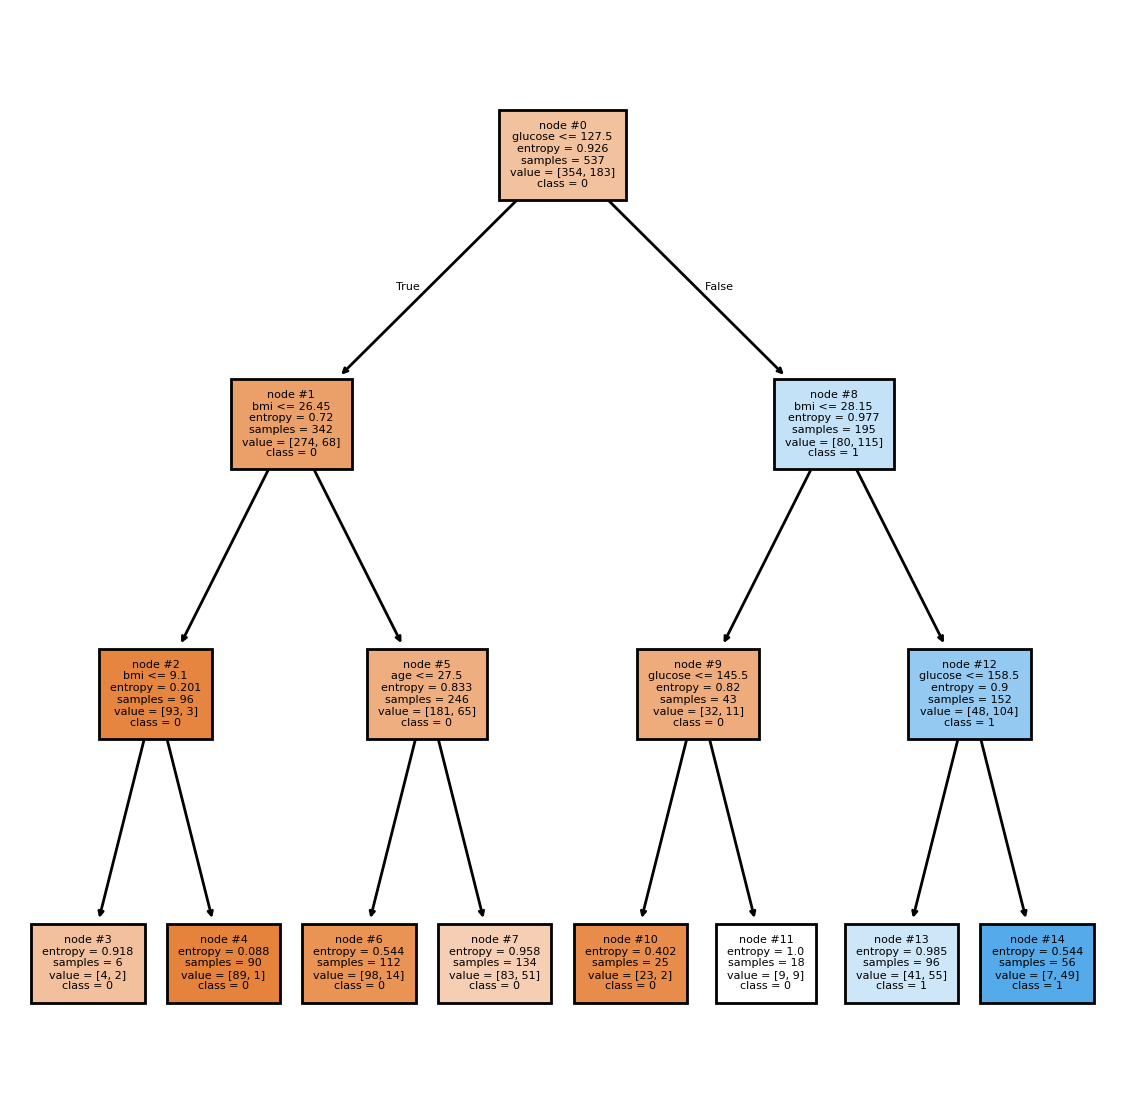

In [ ]:
from sklearn import tree

# Plot the decision tree with customizations
plt.figure(figsize=(7, 7), dpi=200)
plt.title("Decision Tree Visualization")
tree.plot_tree(clf, filled=True, feature_names=list(X_train.columns), class_names=['0','1'],
                                   fontsize=4, max_depth=4, node_ids=True)
plt.show()